# Multilingual AI for Trust, Safety and Revenue Protection

A Thai–English text-classification system for detecting off-platform
communication and potential policy violations.

**Model:** Multilingual DistilBERT  
**Frameworks:** PyTorch and Hugging Face Transformers  
**Task:** Imbalanced binary text classification

## 1. Project Overview

Online learning and service platforms may experience situations where users
attempt to exchange external contact information or move their conversations
outside the platform.

This project fine-tunes multilingual DistilBERT to classify Thai and English
messages into two categories:

- **Class 0:** No off-platform communication intent
- **Class 1:** Potential off-platform communication or policy violation

The project focuses on the challenges of multilingual text processing,
extreme class imbalance, decision-threshold optimization and responsible
human review.

## 2. Business Objectives

The solution is designed to:

1. Identify potentially policy-violating messages.
2. Reduce the volume of messages requiring manual inspection.
3. Maintain high precision to limit unnecessary moderator alerts.
4. Support user safety, platform compliance and revenue protection.
5. Provide probability scores for human-review prioritization.

## 3. Data Privacy and Responsible AI

The original data is not included in this repository because it may contain
confidential user conversations and personally identifiable information.

Any public demonstration data included with this project is synthetic or
fully anonymized. Model predictions should support trained human reviewers
rather than serve as the sole basis for punitive action.

In [ ]:
import os
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed,
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
)

from sklearn.model_selection import train_test_split

In [ ]:
import importlib.util


print("PyTorch version:", torch.__version__)
print("CUDA version:", torch.version.cuda)
print("GPU available:", torch.cuda.is_available())
print(
    "Torchvision installed:",
    importlib.util.find_spec("torchvision") is not None
)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected—do not start training.")

PyTorch version: 2.11.0+cu128
CUDA version: 12.8
GPU available: True
Torchvision installed: True
GPU: Tesla T4


## 4. Configuration and Reproducibility

A fixed random seed is used to make the dataset split and model-training
process more reproducible.

In [ ]:
SEED = 42
MODEL_NAME = "distilbert-base-multilingual-cased"
MAX_LENGTH = 64

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


## 5. Data Loading

The original operational dataset is private and is not distributed with
this project. The notebook expects a CSV file containing:

- `text`: the input message
- `label`: the binary target, where 0 is negative and 1 is positive

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

DATA_PATH = Path(
    "/content/drive/MyDrive/input/"
    "selected_3000_negative_plus_all_positive.csv"
)

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/multilingual_trust_safety_outputs"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

Mounted at /content/drive


In [ ]:
df = pd.read_csv(DATA_PATH)

required_columns = {"text", "label"}
missing_columns = required_columns - set(df.columns)

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

df = df[["text", "label"]].copy()

# Clean the text before converting missing values to strings.
df["text"] = df["text"].fillna("").astype(str).str.strip()
df["label"] = pd.to_numeric(df["label"], errors="coerce")

df = df.dropna(subset=["label"])
df["label"] = df["label"].astype(int)

df = df[df["text"] != ""]
df = df[df["label"].isin([0, 1])]
df = df.drop_duplicates(subset=["text", "label"]).reset_index(drop=True)

print(f"Total rows: {len(df):,}")
print(df["label"].value_counts().sort_index())

Total rows: 3,044
label
0    3000
1      44
Name: count, dtype: int64


## 6. Dataset Summary

The experiment uses a curated labeled subset of 3,044 multilingual messages
drawn from a larger operational corpus.

The labeled dataset is extremely imbalanced, with policy-violating messages
representing approximately 1.45% of all examples. Because of this imbalance,
accuracy alone is not an appropriate measure of model quality.

In [ ]:
class_summary = (
    df["label"]
    .value_counts()
    .sort_index()
    .rename_axis("label")
    .reset_index(name="count")
)

class_summary["class_name"] = class_summary["label"].map({
    0: "Negative",
    1: "Positive",
})

class_summary["percentage"] = (
    class_summary["count"] / class_summary["count"].sum() * 100
)

class_summary[["class_name", "count", "percentage"]]

,class_name,count,percentage
0,Negative,3000,98.554534
1,Positive,44,1.445466


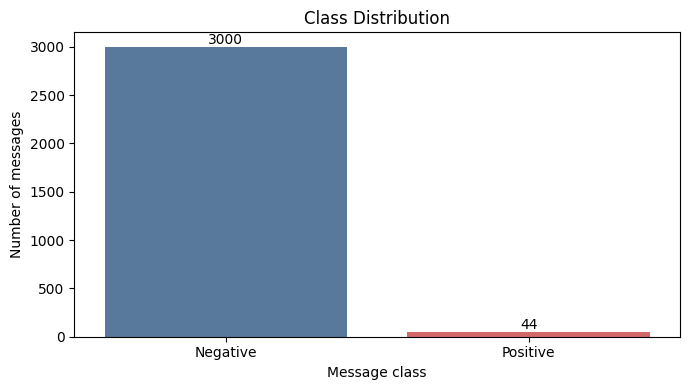

In [ ]:
plt.figure(figsize=(7, 4))

ax = sns.barplot(
    data=class_summary,
    x="class_name",
    y="count",
    hue="class_name",
    palette=["#4C78A8", "#E45756"],
    legend=False,
)

plt.title("Class Distribution")
plt.xlabel("Message class")
plt.ylabel("Number of messages")

for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.show()

## 7. Data-Quality and Leakage Checks

Duplicate or contradictory labels can produce unreliable evaluation results.
The following checks are performed before splitting the dataset.

In [ ]:
exact_duplicate_count = df.duplicated(
    subset=["text", "label"]
).sum()

contradictory_labels = (
    df.groupby("text")["label"]
    .nunique()
    .loc[lambda values: values > 1]
)

print(f"Exact duplicate rows: {exact_duplicate_count}")
print(f"Texts with contradictory labels: {len(contradictory_labels)}")

Exact duplicate rows: 0
Texts with contradictory labels: 0


## 8. Dataset Splitting

The data is divided into training, validation and held-out test sets using
stratified sampling:

- 52% training
- 24% validation
- 24% testing

Stratification preserves the positive-class proportion across the three
datasets. The validation set is used for model selection and threshold
optimization. The test set is evaluated only after the threshold is selected.

In [ ]:
train_df, temporary_df = train_test_split(
    df,
    test_size=0.48,
    stratify=df["label"],
    random_state=SEED,
)

valid_df, test_df = train_test_split(
    temporary_df,
    test_size=0.50,
    stratify=temporary_df["label"],
    random_state=SEED,
)

split_summary = pd.DataFrame({
    "split": ["Training", "Validation", "Test"],
    "total": [len(train_df), len(valid_df), len(test_df)],
    "positive": [
        int(train_df["label"].sum()),
        int(valid_df["label"].sum()),
        int(test_df["label"].sum()),
    ],
})

split_summary["negative"] = (
    split_summary["total"] - split_summary["positive"]
)

split_summary

,split,total,positive,negative
0,Training,1582,23,1559
1,Validation,731,11,720
2,Test,731,10,721


In [ ]:

train_ds = Dataset.from_pandas(
    train_df.reset_index(drop=True),
    preserve_index=False,
)

valid_ds = Dataset.from_pandas(
    valid_df.reset_index(drop=True),
    preserve_index=False,
)

test_ds = Dataset.from_pandas(
    test_df.reset_index(drop=True),
    preserve_index=False,
)

print("Original training format:", train_ds.format)
print("Original columns:", train_ds.column_names)



Original training format: {'type': None, 'format_kwargs': {}, 'columns': ['text', 'label'], 'output_all_columns': False}
Original columns: ['text', 'label']


## 9. Tokenization

The project uses the tokenizer associated with multilingual DistilBERT.
Messages are truncated or padded to a maximum sequence length of 64 tokens.

In [ ]:

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )

# Tokenize while removing raw text from model datasets
train_ds = train_ds.map(
    tokenize,
    batched=True,
    remove_columns=["text"],
)

valid_ds = valid_ds.map(
    tokenize,
    batched=True,
    remove_columns=["text"],
)

test_ds = test_ds.map(
    tokenize,
    batched=True,
    remove_columns=["text"],
)

# Rename the target column for Hugging Face Trainer
train_ds = train_ds.rename_column("label", "labels")
valid_ds = valid_ds.rename_column("label", "labels")
test_ds = test_ds.rename_column("label", "labels")

# Keep standard Hugging Face format
train_ds.reset_format()
valid_ds.reset_format()
test_ds.reset_format()

print("\nTokenization completed successfully")
print("Training format:", train_ds.format)
print("Training columns:", train_ds.column_names)
print("Training rows:", len(train_ds))
print("Validation rows:", len(valid_ds))
print("Test rows:", len(test_ds))

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

Map:   0%|          | 0/1582 [00:00<?, ? examples/s]

Map:   0%|          | 0/731 [00:00<?, ? examples/s]

Map:   0%|          | 0/731 [00:00<?, ? examples/s]


Tokenization completed successfully
Training format: {'type': None, 'format_kwargs': {}, 'columns': ['labels', 'input_ids', 'token_type_ids', 'attention_mask'], 'output_all_columns': False}
Training columns: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']
Training rows: 1582
Validation rows: 731
Test rows: 731


## 10. Model

`distilbert-base-multilingual-cased` is a compact multilingual Transformer
supporting more than 100 languages. A new binary-classification head is added
and fine-tuned for the target task.

In [ ]:

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  542MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
def compute_metrics(eval_prediction):
    logits, labels = eval_prediction

    probabilities = torch.softmax(
        torch.tensor(logits), dim=1
    ).numpy()

    predictions = np.argmax(probabilities, axis=1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision_score(
            labels, predictions, zero_division=0
        ),
        "recall": recall_score(
            labels, predictions, zero_division=0
        ),
        "f1": f1_score(
            labels, predictions, zero_division=0
        ),
    }

## 11. Model Training

The model is trained for a maximum of 10 epochs. Validation loss is monitored
after every epoch, and early stopping ends training if the loss does not
improve for two consecutive epochs.

In [ ]:
training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    logging_steps=10,
    save_total_limit=1,
    report_to="none",
    seed=SEED,
    data_seed=SEED,
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=valid_ds,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=2)
    ],
)

In [ ]:
test_dataloader = trainer.get_train_dataloader()
first_batch = next(iter(test_dataloader))

print("Batch loaded successfully")
print("Available keys:", first_batch.keys())
print("Input shape:", first_batch["input_ids"].shape)
print("Attention-mask shape:", first_batch["attention_mask"].shape)
print("Labels shape:", first_batch["labels"].shape)

Batch loaded successfully
Available keys: dict_keys(['labels', 'input_ids', 'attention_mask'])
Input shape: torch.Size([8, 64])
Attention-mask shape: torch.Size([8, 64])
Labels shape: torch.Size([8])


In [ ]:
start_time = time.perf_counter()

training_result = trainer.train()

runtime_seconds = time.perf_counter() - start_time

print(f"Training runtime: {runtime_seconds:.2f} seconds")

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.077478,0.089263,0.984952,0.000000,0.000000,0.000000
2,0.003186,0.089261,0.984952,0.000000,0.000000,0.000000
3,0.002696,0.108868,0.978112,0.222222,0.181818,0.200000
4,0.011040,0.086334,0.984952,0.500000,0.181818,0.266667
5,0.000675,0.106159,0.980848,0.333333,0.272727,0.300000
6,0.000510,0.109196,0.982216,0.400000,0.363636,0.380952


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training runtime: 178.03 seconds


In [ ]:
validation_metrics = trainer.evaluate(valid_ds)
validation_metrics

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.000510,0.086334,6,0.984952,0.500000,0.181818,0.266667


{'eval_loss': 0.08633352816104889,
 'eval_accuracy': 0.9849521203830369,
 'eval_precision': 0.5,
 'eval_recall': 0.18181818181818182,
 'eval_f1': 0.26666666666666666}

In [ ]:
#Save Model
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/multilingual_trust_safety_outputs/tokenizer_config.json',
 '/content/drive/MyDrive/multilingual_trust_safety_outputs/tokenizer.json')

The default prediction uses `argmax`, which is equivalent to selecting the
class with the highest model probability. Because the positive class is rare,
a separate validation procedure is used to select a more appropriate
probability threshold.

In [ ]:
validation_predictions = trainer.predict(valid_ds)

validation_logits = validation_predictions.predictions
validation_labels = validation_predictions.label_ids

validation_probabilities = torch.softmax(
    torch.tensor(validation_logits), dim=1
).numpy()[:, 1]

threshold_results = []

for threshold in np.arange(0.01, 0.96, 0.01):
    predicted_labels = (
        validation_probabilities >= threshold
    ).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(
            validation_labels, predicted_labels
        ),
        "precision": precision_score(
            validation_labels,
            predicted_labels,
            zero_division=0,
        ),
        "recall": recall_score(
            validation_labels,
            predicted_labels,
            zero_division=0,
        ),
        "f1": f1_score(
            validation_labels,
            predicted_labels,
            zero_division=0,
        ),
    })

threshold_df = pd.DataFrame(threshold_results)

best_row = threshold_df.loc[threshold_df["f1"].idxmax()]
BEST_THRESHOLD = float(best_row["threshold"])

print(f"Selected threshold: {BEST_THRESHOLD:.2f}")
best_row

Selected threshold: 0.01


,0
threshold,0.010000
accuracy,0.986320
precision,0.600000
recall,0.272727
f1,0.375000


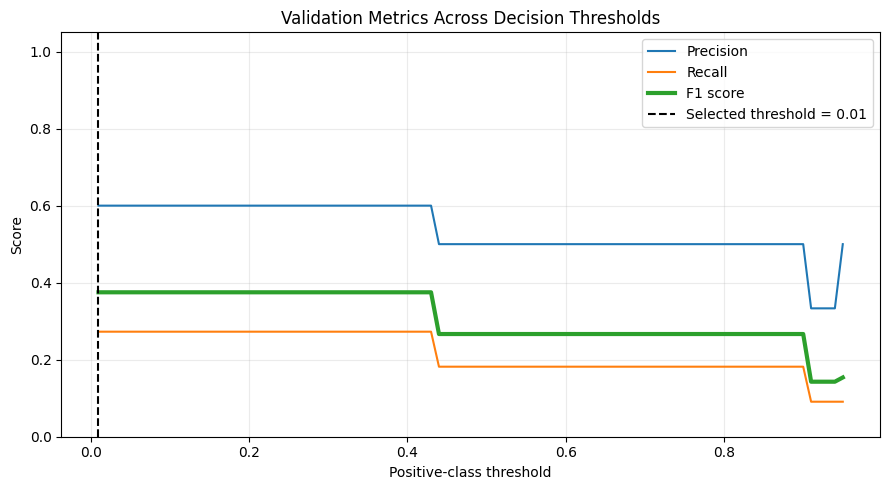

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_df["threshold"],
    threshold_df["precision"],
    label="Precision",
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["recall"],
    label="Recall",
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["f1"],
    label="F1 score",
    linewidth=3,
)

plt.axvline(
    BEST_THRESHOLD,
    color="black",
    linestyle="--",
    label=f"Selected threshold = {BEST_THRESHOLD:.2f}",
)

plt.title("Validation Metrics Across Decision Thresholds")
plt.xlabel("Positive-class threshold")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 12. Held-Out Test Evaluation

The test set is evaluated only after model selection and threshold
optimization are complete.

In [ ]:
test_predictions = trainer.predict(test_ds)

test_logits = test_predictions.predictions
test_labels = test_predictions.label_ids

test_probabilities = torch.softmax(
    torch.tensor(test_logits), dim=1
).numpy()[:, 1]

test_predicted_labels = (
    test_probabilities >= BEST_THRESHOLD
).astype(int)

test_metrics = {
    "accuracy": accuracy_score(
        test_labels, test_predicted_labels
    ),
    "precision": precision_score(
        test_labels,
        test_predicted_labels,
        zero_division=0,
    ),
    "recall": recall_score(
        test_labels,
        test_predicted_labels,
        zero_division=0,
    ),
    "f1": f1_score(
        test_labels,
        test_predicted_labels,
        zero_division=0,
    ),
}

pd.Series(test_metrics).round(4)

,0
accuracy,0.9932
precision,0.8571
recall,0.6000
f1,0.7059


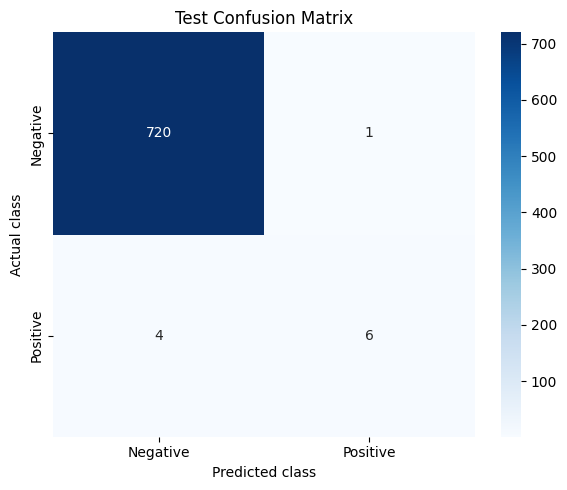

In [ ]:
matrix = confusion_matrix(
    test_labels,
    test_predicted_labels,
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"],
)

plt.title("Test Confusion Matrix")
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.tight_layout()
plt.show()

## 13. Error Analysis

Error analysis examines false positives and false negatives to understand
where the model may create unnecessary alerts or fail to identify potentially
risky messages.

Real messages are not displayed in the public notebook. Only anonymous
record indexes and prediction probabilities are reported.

In [ ]:
error_analysis = pd.DataFrame({
    "actual_label": test_labels,
    "predicted_label": test_predicted_labels,
    "positive_probability": test_probabilities,
})

false_positives = error_analysis[
    (error_analysis["actual_label"] == 0) &
    (error_analysis["predicted_label"] == 1)
]

false_negatives = error_analysis[
    (error_analysis["actual_label"] == 1) &
    (error_analysis["predicted_label"] == 0)
]

print(f"False positives: {len(false_positives)}")
print(f"False negatives: {len(false_negatives)}")

False positives: 1
False negatives: 4


## 14. Test Results

Using a decision threshold selected exclusively from the validation set, the model achieved the following results on the held-out test set:

| Metric    | Result |
| --------- | -----: |
| Accuracy  | 99.32% |
| Precision | 85.71% |
| Recall    | 60.00% |
| F1 score  | 70.59% |

The model correctly detected 6 of the 10 positive test examples while generating only one false-positive alert. Its precision of 85.71% indicates that approximately six out of every seven flagged messages were correctly classified as potential policy violations.

The recall of 60.00% shows that the model missed four positive examples. This highlights the trade-off between maintaining high precision and detecting a larger proportion of potential violations.

Accuracy is not treated as the primary performance measure because the dataset is extremely imbalanced. Precision, recall, and F1 score provide a more meaningful assessment of positive-class performance.

Because the held-out test set contains only 10 positive examples, these results should be considered preliminary rather than a definitive estimate of production performance.


## 15. Limitations

This experiment has several important limitations:

- The labeled dataset contains only 44 positive examples.
- The held-out test set contains only 10 positive examples.
- A single prediction can therefore change precision, recall and F1
  substantially.
- The dataset may not represent every type of Thai or English off-platform
  communication.
- Similar messages from related conversations could potentially appear
  across splits if conversation identifiers are unavailable.
- Performance may change when the model encounters new language patterns,
  slang or indirect contact-sharing attempts.

The reported results should therefore be considered preliminary rather
than a definitive estimate of production performance.

## 16. Future Improvements

Potential improvements include:

1. Collecting additional human-labeled positive examples.
2. Splitting data at the conversation level to reduce leakage risk.
3. Comparing class-weighted cross-entropy and focal loss.
4. Applying stratified cross-validation.
5. Comparing multilingual DistilBERT with XLM-RoBERTa.
6. Evaluating Thai and English examples separately.
7. Adding confidence intervals to model metrics.
8. Monitoring data drift and model performance over time.
9. Maintaining human review for consequential moderation decisions.

## 17. Conclusion

This project demonstrates an end-to-end multilingual NLP workflow for a
highly imbalanced Trust and Safety classification problem.

The solution includes data validation, multilingual tokenization,
Transformer fine-tuning, validation-based threshold optimization,
held-out testing, error analysis and responsible-AI considerations.

Although the limited number of positive examples prevents strong claims
about production generalization, the experiment demonstrates how an NLP
model can support human reviewers by prioritizing potentially risky
messages for further assessment.